In [2]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

import tiktoken

In [3]:
tokenizer = tiktoken.get_encoding("cl100k_base") # GPT4 tokenizer

In [4]:
# data hyperparameters
context_size = 8 # sequence length
stride = 2 # how many tokens to skip between sequences
n_vocab = tokenizer.n_vocab

# model hyperparameters
batch_size = 5
embedding_dim = 64

In [5]:
# get raw text of the Time Machine by H.G. Wells
url = 'https://www.gutenberg.org/files/35/35-0.txt'
response = requests.get(url)
text = response.text

tokens = tokenizer.encode(text)
tokens_tensor = torch.tensor(tokens, dtype=torch.long)

print(f"Number of tokens in the dataset: {len(tokens_tensor)}")

Number of tokens in the dataset: 43053


In [6]:
class TextDataset(Dataset):
    def __init__(self, tokens_tensor, context_size=8, stride=2):
        
        # build all windows at once using unfold
        self.inputs  = tokens_tensor.unfold(0, context_size, stride)       # (num_windows, context_size)
        self.targets = tokens_tensor[1:].unfold(0, context_size, stride)    # shifted by 1

        # make sure both have the same number of windows
        min_len = min(len(self.inputs), len(self.targets))
        self.inputs  = self.inputs[:min_len]
        self.targets = self.targets[:min_len]

    def __len__(self):
        return len(self.inputs)  # number of windows, not tokens

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]  # each is (context_size,)


token_dataset = TextDataset(tokens_tensor, context_size, stride)
token_dataloader = DataLoader(token_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super().__init__()

        # embedding layer to convert word indices to embeddings (for example token 1234 will be mapped to a vector of size embedding_dim)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # unembedding (linear layer) to convert the output of the model back to vocab size logits
        self.gelu = nn.GELU() # 
        self.fc1 = nn.Linear(embedding_dim, vocab_size, bias=False) 

    def forward(self, tok_x):
        # tok_x: (batch_size, context_size) — token indices

        # the operation applied here is a simple lookup in the embedding matrix, so it's very efficient. 1 token index -> 1 embedding vector
        embedded = self.embedding(tok_x) # each token index is mapped to a vector of size embedding_dim
        # embedded: (batch_size, context_size, embedding_dim)

        activated = self.gelu(embedded) # apply non-linearity
        # activated: (batch_size, context_size, embedding_dim)
        
        out = self.fc1(activated) # project back to vocab size
        # out: (batch_size, context_size, vocab_size) — raw logits

        return out

    
    def generate(self, tok_x, max_new_tokens):
        # tok_x: (batch_size, context_size) — token indices

        for _ in range(max_new_tokens):
            
            out = self.forward(tok_x) # get the model's predictions for the next token 
            # out: (batch_size, context_size, vocab_size)
            
            next_token_logits = out[:, -1, :] # we only care about the last token's logits, since that's what we'll use to predict the next token
            # next_token_logits: (batch_size, vocab_size)
            
            # apply softmax to convert logits to probabilities
            next_token_probs = F.softmax(next_token_logits, dim=1) 
            # next_token_probs: (batch_size, vocab_size)
            
            # sample the next token from the probability distribution
            next_token = torch.multinomial(next_token_probs, num_samples=1)
            # next_token: (batch_size, 1) — we sample one token for each example in the batch
                        
            tok_x = torch.cat([tok_x, next_token], dim=1) # append the predicted token to the input sequence

        return tok_x

model = GPTModel(n_vocab, embedding_dim, context_size)
print(model)

GPTModel(
  (embedding): Embedding(100277, 64)
  (gelu): GELU(approximate='none')
  (fc1): Linear(in_features=64, out_features=100277, bias=False)
)


In [9]:
class GPTModel2(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super().__init__()

        self.context_size = context_size

        # TOKEN embedding: maps each token ID → a learned vector
        # Lookup table of shape (vocab_size, embedding_dim)
        # Example: token id 1234 → vector of size embedding_dim
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)

        # POSITIONAL embedding: maps each position index → a learned vector
        # Lookup table of shape (context_size, embedding_dim)
        #
        # Example: position 0 → vector of size embedding_dim
        #          position 1 → a different vector of size embedding_dim
        #          ...
        self.pos_embedding = nn.Embedding(context_size, embedding_dim)

        # LAYER NORM: normalizes activations to zero mean and unit variance.
        # Placed BEFORE GELU (pre-norm) — current state of the art used in GPT-2, GPT-3, LLaMA, etc.
        # Pre-norm is more stable than post-norm during training of deep networks:
        # gradients flow through the residual path without passing through LN at every layer.
        # Operates on the last dimension only: (..., embedding_dim) → same shape.
        self.norm = nn.LayerNorm(embedding_dim)

        self.gelu = nn.GELU()

        # UNEMBEDDING: projects each embedding vector → vocab_size logits
        # Weight shape: (vocab_size, embedding_dim) — same as token_embedding.weight
        self.fc1 = nn.Linear(embedding_dim, vocab_size, bias=False)

        # WEIGHT TYING: share the token embedding matrix with the unembedding layer.
        # Both map between the same two spaces (token IDs ↔ embedding vectors),
        # so one shared matrix is enough. Benefits:
        #   - Saves vocab_size × embedding_dim parameters (huge for large vocabs)
        #   - Improves generalization (used in GPT-2 and most modern LLMs)
        # nn.Linear stores weights as (out_features, in_features) = (vocab_size, embedding_dim),
        # which matches token_embedding.weight exactly → no transpose needed.
        self.fc1.weight = self.token_embedding.weight

    def forward(self, tok_x):
        # tok_x: (batch_size, context_size) — token indices

        # ── Token embeddings ──────────────────────────────────────────────────
        tok_emb = self.token_embedding(tok_x)
        # tok_emb: (batch_size, context_size, embedding_dim)

        # ── Positional embeddings ─────────────────────────────────────────────
        # Build position indices [0, 1, 2, ..., context_size-1] for every item in the batch.
        # arange gives shape (context_size,); the same positions apply to all batch items.
        positions = torch.arange(self.context_size, device=tok_x.device)
        # positions: (context_size,)

        pos_emb = self.pos_embedding(positions)
        # pos_emb: (context_size, embedding_dim)

        # Broadcasting will expand this to (batch_size, context_size, embedding_dim)
        # when added to tok_emb below.

        # ── Combine: add token + position information ─────────────────────────
        # Each token vector now carries BOTH what the token is AND where it is.
        embedded = tok_emb + pos_emb
        # embedded: (batch_size, context_size, embedding_dim)

        # ── Layer norm BEFORE activation (pre-norm, current SotA) ─────────────
        # Normalize BEFORE the non-linearity so GELU receives stable, well-scaled inputs.
        normed = self.norm(embedded)
        # normed: (batch_size, context_size, embedding_dim) — same shape, now normalized

        activated = self.gelu(normed)
        # activated: (batch_size, context_size, embedding_dim)

        out = self.fc1(activated)
        # out: (batch_size, context_size, vocab_size) — raw logits

        return out

    def generate(self, tok_x, max_new_tokens):
        # tok_x: (batch_size, context_size) — token indices

        for _ in range(max_new_tokens):
            
            # Crop to context_size so positional indices never go out of range
            # as the sequence grows during generation.
            tok_x_crop = tok_x[:, -self.context_size:]
            # tok_x_crop: (batch_size, min(current_len, context_size))

            out = self.forward(tok_x_crop)
            # out: (batch_size, context_size, vocab_size)

            next_token_logits = out[:, -1, :]
            # next_token_logits: (batch_size, vocab_size)

            next_token_probs = F.softmax(next_token_logits, dim=1)
            # next_token_probs: (batch_size, vocab_size)

            next_token = torch.multinomial(next_token_probs, num_samples=1)
            # next_token: (batch_size, 1)

            tok_x = torch.cat([tok_x, next_token], dim=1)

        return tok_x

model2 = GPTModel2(n_vocab, embedding_dim, context_size)
print(model2)


GPTModel2(
  (token_embedding): Embedding(100277, 64)
  (pos_embedding): Embedding(8, 64)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (gelu): GELU(approximate='none')
  (fc1): Linear(in_features=64, out_features=100277, bias=False)
)


In [12]:
# test the model
X_batch, y_batch = next(iter(token_dataloader))
out = model(X_batch) # forward pass

print("Input batch shape:", X_batch.shape) # should be (context_size)
print("Target batch shape:", y_batch.shape) # should be (context_size)
print("Output shape:", out.shape) # should be (context_size, vocab_size)

Input batch shape: torch.Size([5, 8])
Target batch shape: torch.Size([5, 8])
Output shape: torch.Size([5, 8, 100277])


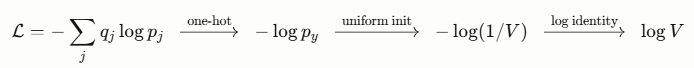

In [21]:
# =========================================================================
# Sanity check: comparing four related quantities at initialization
# =========================================================================

# (1) EXPECTED LOSS for random/uniform weights
#     A freshly initialized model produces ~uniform probabilities over the
#     vocab, so each token has prob ≈ 1/V where V = vocab_size.
#     Cross-entropy on the correct class is therefore -log(1/V) = log(V).
#     This is the theoretical "starting point" loss before any training.
print(f"Expected loss for random weights: {-np.log(1/tokenizer.n_vocab):.3f}")
print(f"Expected loss for random weights: {np.log(tokenizer.n_vocab):.3f}")


# (2) NLL LOSS — Negative Log-Likelihood
#     Takes log-probabilities (already log_softmax'd) and target indices,
#     then picks out the log-prob of the CORRECT class for each token
#     and averages: -mean(log p_{i, y_i}).
#     This IS the actual training loss, just split into two steps.
log_probs = F.log_softmax(out.view(-1, out.shape[-1]), dim=-1)
print(f"NLL loss (manual log_softmax + nll_loss): "
      f"{F.nll_loss(log_probs, y_batch.view(-1)):.3f}")

# (3) CROSS-ENTROPY LOSS from PyTorch
#     Mathematically identical to NLL above, but takes raw logits and
#     does log_softmax internally (more numerically stable than doing
#     log_softmax yourself). This is the standard way to train.
#     At init, this should be ≈ log(V) — matching (1).
print(f"Cross-entropy loss from PyTorch:  "
      f"{F.cross_entropy(out.view(-1, out.shape[-1]), y_batch.view(-1)):.3f}")

Expected loss for random weights: 11.516
Expected loss for random weights: 11.516
NLL loss (manual log_softmax + nll_loss): 11.702
Cross-entropy loss from PyTorch:  11.702


In [24]:
final.shape, n_vocab

(torch.Size([8, 100277]), 100277)

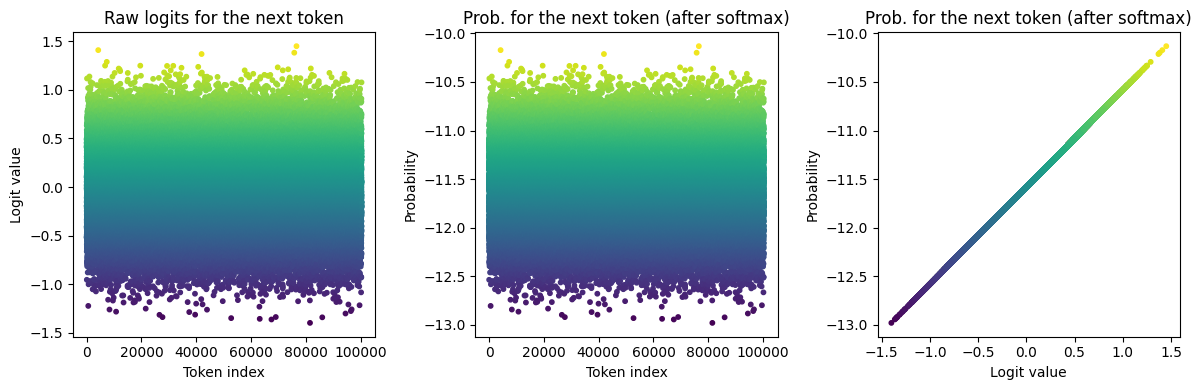

In [ ]:
# test the model's forward pass, and try LOG SOFTMAX instead of softmax

X_batch, y_batch = token_dataset[1234] # get one sequence of data (not a batch yet)
out = model(X_batch) # forward pass
final = out[-1, :].detach() # get the logits for the last token in the sequence, which is what we'll use to predict the next token
softmaxed = F.log_softmax(final, dim=0) # apply softmax to get probabilities

# visualize the raw logits and the probabilities for the next token
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].scatter(range(n_vocab), final, s=10, c=final)
axs[0].set_title("Raw logits for the next token")
axs[0].set_xlabel("Token index")
axs[0].set_ylabel("Logit value")
axs[1].scatter(range(n_vocab), softmaxed, s=10, c=final)
axs[1].set_title("Prob. for the next token (after softmax)")
axs[1].set_xlabel("Token index")
axs[1].set_ylabel("Probability")
axs[2].scatter(final, softmaxed, s=10, c=final)
axs[2].set_title("Prob. for the next token (after softmax)")
axs[2].set_xlabel("Logit value")
axs[2].set_ylabel("Probability")
plt.tight_layout()
plt.show()

# we can see that with log_softmax applies linearity, compared to softmax which is no-linear.